# Phân loại cấp bậc nghề nghiệp từ tin tuyển dụng

## Mục tiêu dự án

Xây dựng mô hình Machine Learning dự đoán `career_level` của một tin tuyển dụng dựa trên:

- tiêu đề công việc (`title`),
- địa điểm (`location`),
- mô tả công việc (`description`),
- nhóm chức năng (`function`),
- ngành nghề (`industry`).

Đây là bài toán **phân loại đa lớp có mất cân bằng dữ liệu rất mạnh**. Vì vậy, ngoài accuracy, notebook đánh giá thêm macro-F1 và balanced accuracy.

## 1. Import thư viện

In [1]:
from pathlib import Path
import html
import re
import warnings

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 100

## 2. Đọc dữ liệu

In [2]:
DATA_PATH = Path("final_project.ods")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy dữ liệu: {DATA_PATH.resolve()}")

data_raw = pd.read_excel(DATA_PATH, dtype=str, engine="odf")
print(f"Kích thước dữ liệu gốc: {data_raw.shape[0]:,} dòng x {data_raw.shape[1]} cột")
display(data_raw.head(3))

Kích thước dữ liệu gốc: 8,074 dòng x 6 cột


,title,location,description,function,industry,career_level
0,Technical Professional Lead - Process,"Houston, TX","Responsible for the study, design, and specifi...",production_manufacturing,Machinery and Industrial Facilities Engineering,senior_specialist_or_project_manager
1,Cnslt - Systems Eng- Midrange 1,"Seattle, WA","Participates in design, development and implem...",information_technology_telecommunications,Financial Services,senior_specialist_or_project_manager
2,SharePoint Developers and Solution Architects,"Dallas, TX",We are currently in need of Developers who can...,consulting,IT Consulting,senior_specialist_or_project_manager


In [3]:
summary = pd.DataFrame({
    "dtype": data_raw.dtypes.astype(str),
    "missing": data_raw.isna().sum(),
    "unique": data_raw.nunique(dropna=True),
})
display(summary)
print(f"Số dòng trùng lặp hoàn toàn: {data_raw.duplicated().sum():,}")

,dtype,missing,unique
title,str,0,6790
location,str,0,1081
description,str,1,7973
function,str,0,19
industry,str,0,352
career_level,str,0,6


Số dòng trùng lặp hoàn toàn: 21


## 3. Làm sạch dữ liệu

- Loại dòng thiếu dữ liệu và dòng trùng lặp.
- Chuẩn hóa khoảng trắng, HTML entities và ký tự `Â` thường xuất hiện do lỗi mã hóa.
- Với địa điểm kiểu `Houston, TX`, lấy mã bang `TX`; các địa điểm khác được giữ nguyên.
- Ghép các trường văn bản để mô hình học đồng thời từ tiêu đề, mô tả và ngành nghề.

In [4]:
REQUIRED_COLUMNS = ["title", "location", "description", "function", "industry", "career_level"]
missing_columns = sorted(set(REQUIRED_COLUMNS) - set(data_raw.columns))
if missing_columns:
    raise ValueError(f"Dữ liệu thiếu cột bắt buộc: {missing_columns}")

def clean_text(value):
    value = html.unescape(str(value)).replace("Â", " ")
    return re.sub(r"\s+", " ", value).strip()

def normalize_location(value):
    value = clean_text(value)
    match = re.search(r"(?:,|\s)\s*([A-Z]{2})$", value)
    return match.group(1) if match else value

data = data_raw[REQUIRED_COLUMNS].dropna().drop_duplicates().copy()
for column in REQUIRED_COLUMNS:
    data[column] = data[column].map(clean_text)

data = data[(data[REQUIRED_COLUMNS] != "").all(axis=1)].copy()
data["location"] = data["location"].map(normalize_location)
data["combined_text"] = (
    data["title"] + " " + data["title"] + " "
    + data["description"] + " " + data["industry"]
)

print(f"Kích thước sau làm sạch: {data.shape[0]:,} dòng")
display(data.head(3))

Kích thước sau làm sạch: 8,052 dòng


,title,location,description,function,industry,career_level,combined_text
0,Technical Professional Lead - Process,TX,"Responsible for the study, design, and specifi...",production_manufacturing,Machinery and Industrial Facilities Engineering,senior_specialist_or_project_manager,Technical Professional Lead - Process Technica...
1,Cnslt - Systems Eng- Midrange 1,WA,"Participates in design, development and implem...",information_technology_telecommunications,Financial Services,senior_specialist_or_project_manager,Cnslt - Systems Eng- Midrange 1 Cnslt - System...
2,SharePoint Developers and Solution Architects,TX,We are currently in need of Developers who can...,consulting,IT Consulting,senior_specialist_or_project_manager,SharePoint Developers and Solution Architects ...


## 4. Phân tích phân bố nhãn

,count,percentage
career_level,,
senior_specialist_or_project_manager,4323,53.69
manager_team_leader,2667,33.12
bereichsleiter,958,11.90
director_business_unit_leader,70,0.87
specialist,30,0.37
managing_director_small_medium_company,4,0.05


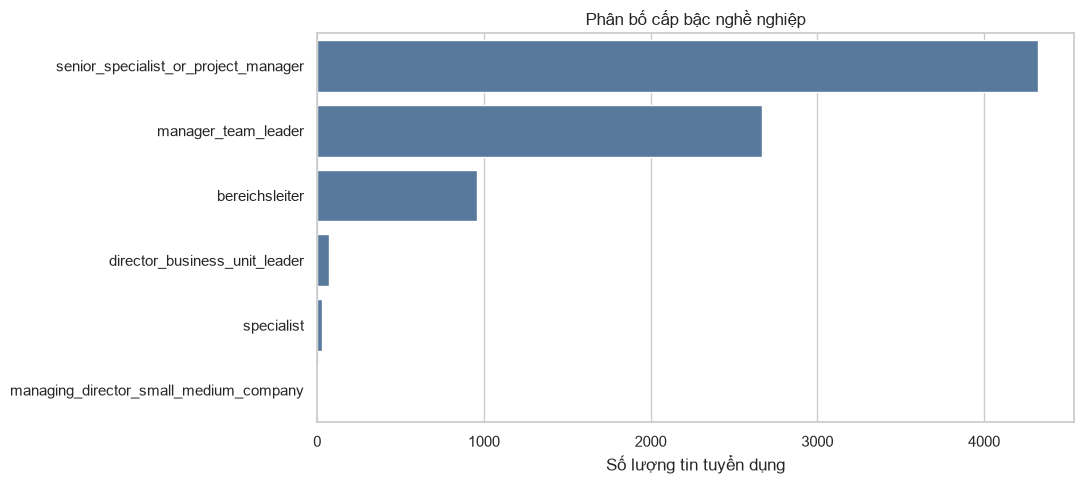

In [5]:
class_counts = data["career_level"].value_counts()
class_table = pd.DataFrame({
    "count": class_counts,
    "percentage": (class_counts / len(data) * 100).round(2),
})
display(class_table)

plt.figure(figsize=(11, 5))
sns.barplot(x=class_counts.values, y=class_counts.index, color="#4C78A8")
plt.title("Phân bố cấp bậc nghề nghiệp")
plt.xlabel("Số lượng tin tuyển dụng")
plt.ylabel("")
plt.tight_layout()
plt.show()

> **Lưu ý:** lớp `managing_director_small_medium_company` chỉ có vài mẫu. Kết quả của lớp này không ổn định và chưa đủ dữ liệu để khẳng định mô hình có thể tổng quát hóa tốt.

## 5. Chia tập train/test

Dùng `stratify=y` để giữ tỷ lệ các lớp gần giống nhau giữa train và test.

In [6]:
FEATURE_COLUMNS = ["combined_text", "location", "function"]
TARGET = "career_level"

X = data[FEATURE_COLUMNS]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {len(X_train):,} mẫu")
print(f"Test:  {len(X_test):,} mẫu")
display(pd.DataFrame({"train": y_train.value_counts(), "test": y_test.value_counts()}).fillna(0).astype(int))

Train: 6,441 mẫu
Test:  1,611 mẫu


,train,test
career_level,,
senior_specialist_or_project_manager,3458,865
manager_team_leader,2134,533
bereichsleiter,766,192
director_business_unit_leader,56,14
specialist,24,6
managing_director_small_medium_company,3,1


## 6. Hàm đánh giá

- **Accuracy:** tỷ lệ dự đoán đúng tổng thể, dễ bị chi phối bởi lớp lớn.
- **Macro-F1:** tính F1 riêng cho từng lớp rồi lấy trung bình, phù hợp để theo dõi lớp hiếm.
- **Balanced accuracy:** trung bình recall của các lớp.

In [7]:
def evaluate_model(name, y_true, y_pred):
    scores = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }
    display(pd.DataFrame([scores]).set_index("model").round(4))
    print(classification_report(y_true, y_pred, zero_division=0))
    return scores

## 7. Baseline

Baseline luôn đoán lớp phổ biến nhất. Mô hình chính phải vượt baseline này một cách rõ ràng.

In [8]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_scores = evaluate_model("Most-frequent baseline", y_test, baseline_pred)

,accuracy,macro_f1,weighted_f1,balanced_accuracy
model,,,,
Most-frequent baseline,0.5369,0.1165,0.3752,0.1667


                                        precision    recall  f1-score   support

                        bereichsleiter       0.00      0.00      0.00       192
         director_business_unit_leader       0.00      0.00      0.00        14
                   manager_team_leader       0.00      0.00      0.00       533
managing_director_small_medium_company       0.00      0.00      0.00         1
  senior_specialist_or_project_manager       0.54      1.00      0.70       865
                            specialist       0.00      0.00      0.00         6

                              accuracy                           0.54      1611
                             macro avg       0.09      0.17      0.12      1611
                          weighted avg       0.29      0.54      0.38      1611



## 8. Tiền xử lý và huấn luyện mô hình

- `TF-IDF` biến văn bản thành đặc trưng unigram + bigram.
- `OneHotEncoder` xử lý địa điểm và nhóm chức năng.
- `LinearSVC` phù hợp với dữ liệu văn bản nhiều chiều và dạng ma trận thưa.
- `class_weight='balanced'` tăng mức phạt khi dự đoán sai các lớp hiếm.

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                stop_words="english",
                ngram_range=(1, 2),
                min_df=3,
                max_df=0.98,
                max_features=50_000,
                sublinear_tf=True,
            ),
            "combined_text",
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", min_frequency=2),
            ["location", "function"],
        ),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)

model.fit(X_train, y_train)
model_pred = model.predict(X_test)
model_scores = evaluate_model("TF-IDF + LinearSVC", y_test, model_pred)

,accuracy,macro_f1,weighted_f1,balanced_accuracy
model,,,,
TF-IDF + LinearSVC,0.7871,0.5406,0.7793,0.4917


                                        precision    recall  f1-score   support

                        bereichsleiter       0.55      0.41      0.47       192
         director_business_unit_leader       0.80      0.57      0.67        14
                   manager_team_leader       0.72      0.72      0.72       533
managing_director_small_medium_company       0.00      0.00      0.00         1
  senior_specialist_or_project_manager       0.86      0.92      0.89       865
                            specialist       1.00      0.33      0.50         6

                              accuracy                           0.79      1611
                             macro avg       0.66      0.49      0.54      1611
                          weighted avg       0.78      0.79      0.78      1611



## 9. So sánh và ma trận nhầm lẫn

,accuracy,macro_f1,weighted_f1,balanced_accuracy
model,,,,
Most-frequent baseline,0.5369,0.1165,0.3752,0.1667
TF-IDF + LinearSVC,0.7871,0.5406,0.7793,0.4917


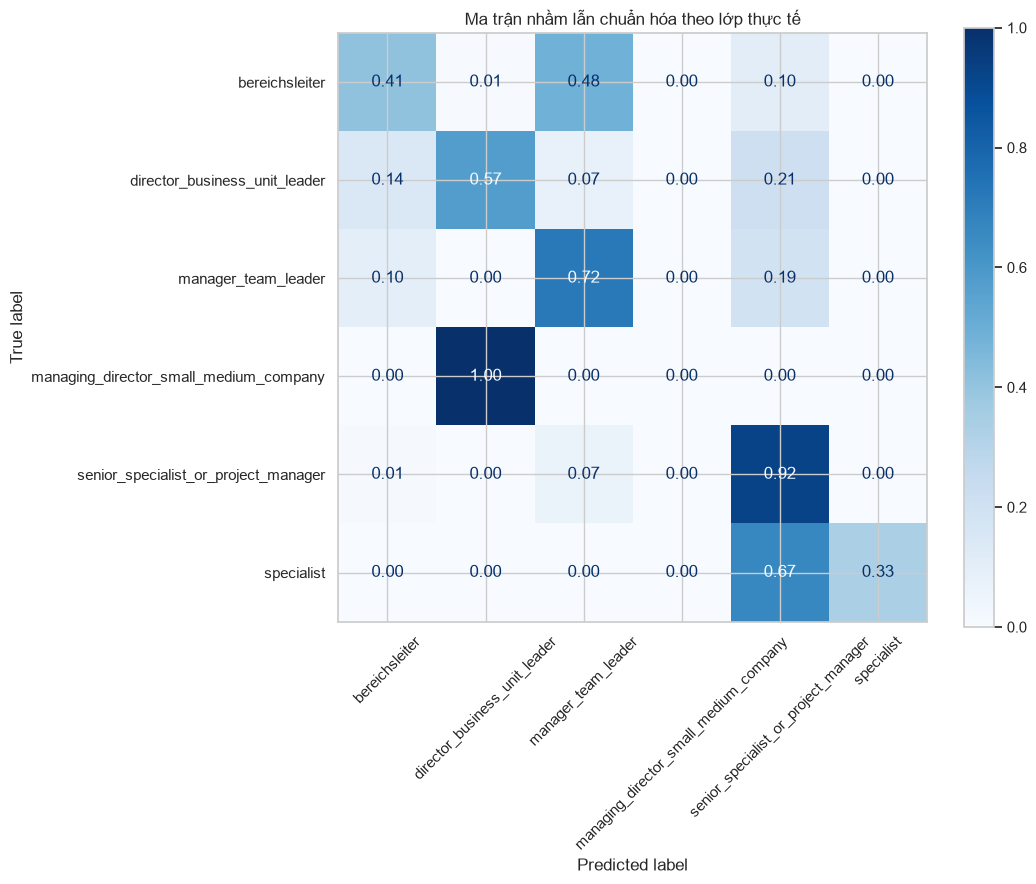

In [10]:
comparison = pd.DataFrame([baseline_scores, model_scores]).set_index("model")
display(comparison.round(4))

fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    model_pred,
    normalize="true",
    xticks_rotation=45,
    cmap="Blues",
    values_format=".2f",
    ax=ax,
)
plt.title("Ma trận nhầm lẫn chuẩn hóa theo lớp thực tế")
plt.tight_layout()
plt.show()

## 10. Xem các dự đoán sai

In [11]:
errors = data.loc[X_test.index, ["title", "location", "function", "career_level"]].copy()
errors["predicted_level"] = model_pred
errors = errors[errors["career_level"] != errors["predicted_level"]]
print(f"Số dự đoán sai: {len(errors):,}/{len(y_test):,}")
display(errors.head(20))

Số dự đoán sai: 343/1,611


,title,location,function,career_level,predicted_level
4546,Senior Vice President of Data Operations,MA,information_technology_telecommunications,bereichsleiter,manager_team_leader
1796,"Senior Manager, Commercial Counsel",NC,legal,manager_team_leader,senior_specialist_or_project_manager
4682,Global Medical Affairs Category Head,NJ,research_development,senior_specialist_or_project_manager,manager_team_leader
1783,EXPERT CONSULTANT,NY,consulting,senior_specialist_or_project_manager,manager_team_leader
7844,Dir NOC Operations,GA,information_technology_telecommunications,manager_team_leader,bereichsleiter
1628,"VP, Global Business Development",NJ,sales,manager_team_leader,senior_specialist_or_project_manager
2738,"Sr. Manager, Product Marketing - Mobile",CA,marketing,senior_specialist_or_project_manager,manager_team_leader
6900,Director of Engineering,FL,research_development,manager_team_leader,bereichsleiter
6856,"Director, North America Marketing & Strategy (...",TX,marketing,bereichsleiter,manager_team_leader
2334,Technical Lead,CA,production_manufacturing,senior_specialist_or_project_manager,bereichsleiter


## 11. Dự đoán tin tuyển dụng mới

In [12]:
def predict_career_level(title, location, description, function, industry):
    title = clean_text(title)
    sample = pd.DataFrame({
        "combined_text": [f"{title} {title} {clean_text(description)} {clean_text(industry)}"],
        "location": [normalize_location(location)],
        "function": [clean_text(function)],
    })
    return model.predict(sample)[0]

example_prediction = predict_career_level(
    title="Senior Software Engineering Manager",
    location="Austin, TX",
    description="Lead a team of software engineers, plan delivery, mentor staff and manage projects.",
    function="information_technology_telecommunications",
    industry="Information Technology",
)
print("Cấp bậc dự đoán:", example_prediction)

Cấp bậc dự đoán: manager_team_leader


## 12. Lưu mô hình

In [13]:
MODEL_PATH = Path("job_level_classifier.joblib")
joblib.dump(model, MODEL_PATH)
print(f"Đã lưu mô hình tại: {MODEL_PATH.resolve()}")

Đã lưu mô hình tại: D:\Code\Code dạo\Python\FInal\job_level_classifier.joblib


## Kết luận và hướng phát triển

Notebook đã hoàn thiện quy trình: đọc dữ liệu → làm sạch → EDA → chia dữ liệu → baseline → huấn luyện → đánh giá → dự đoán mới → lưu mô hình.

Hạn chế quan trọng nhất là các lớp hiếm có quá ít mẫu, đặc biệt lớp chỉ có vài quan sát. Muốn cải thiện độ tin cậy, nên:

1. thu thập thêm dữ liệu cho các lớp hiếm;
2. kiểm tra và chuẩn hóa nhãn bằng chuyên gia nghiệp vụ;
3. thử cross-validation sau khi mỗi lớp có đủ mẫu;
4. tinh chỉnh `C`, `min_df`, số lượng đặc trưng và chiến lược resampling chỉ trên tập train.